ModuleNotFoundError: No module named 'app.loaders'

In [ ]:
from __future__ import annotations


from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition

from app.graph.state import ChatState

from app.graph.nodes import chat_node
from app.graph.tool_node import tool_node
from app.graph.not_found import not_found_answer_node
from app.graph.web_serach import web_search_node
from app.graph.fin_ans import final_answer_node
from app.graph.crag_grader import crag_relevance_grader
from app.graph.hitl import human_approval_node

from langchain_core.messages import ToolMessage

from app.memory.sqlite_memory import checkpointer
from app.memory.stm import summarize_memory

from app.utils.logger import get_logger


logger = get_logger(__name__)


MAX_MESSAGES_BEFORE_SUMMARY = 12


# ============================================================
# MEMORY CHECK
# ============================================================

def should_summarize(state: ChatState):
    """
    Decide whether conversation memory should be summarized.
    """

    messages = state.get("messages", [])

    message_count = len(messages)

    logger.info(
        f"[MEMORY] Current message count: {message_count}"
    )

    print(
        f"[MEMORY] Current message count: {message_count}"
    )

    if message_count > MAX_MESSAGES_BEFORE_SUMMARY:

        logger.info(
            "[MEMORY] Conversation too large -> summarizing"
        )

        print(
            "[MEMORY] Conversation too large -> summarizing"
        )

        return "summarize_memory"

    logger.info(
        "[MEMORY] Conversation size OK -> END"
    )

    print(
        "[MEMORY] Conversation size OK -> END"
    )

    return "end"


# route after Hitl 

def route_after_hitl(state: ChatState):

    decision = state.get(
        "hitl_decision",
        "no"
    )

    decision = str(
        decision
    ).lower().strip()

    print("\n" + "=" * 80)
    print("[HITL ROUTER]")
    print("=" * 80)

    print(
        f"[HITL ROUTER] Decision: {decision}"
    )

    if decision == "yes":

        print(
            "[HITL ROUTER] YES → web_search"
        )

        return "web_search"

    print(
        "[HITL ROUTER] NO → not_found_answer"
    )

    return "not_found_answer"

# ============================================================
# ROUTE AFTER CHAT NODE
# ============================================================

def route_after_chat(state: ChatState):
    """
    Decide whether the LLM wants to call a tool.
    """

    result = tools_condition(state)

    if result == "tools":

        print(
            "[ROUTER] LLM requested tool → tools"
        )

        return "tools"

    print(
        "[ROUTER] No tool requested → memory_check"
    )

    return "memory_check"




# ============================================================
# ROUTE AFTER TOOLS
# ============================================================

def route_after_tools(state: ChatState):
    """
    Decide what happens after tool execution.

    RAG:
        → CRAG grader

    Other tools:
        → chat_node
    """

    messages = state.get("messages", [])

    if not messages:
        return "chat_node"

    for message in reversed(messages):

        if isinstance(message, ToolMessage):

            print(
                f"[ROUTER] Tool executed: {message.name}"
            )

            # ------------------------------------------------
            # RAG
            # ------------------------------------------------

            if message.name == "unified_rag_tool":

                print(
                    "[ROUTER] RAG tool detected → CRAG grader"
                )

                return "crag_grader"

            # ------------------------------------------------
            # OTHER TOOLS
            # ------------------------------------------------

            print(
                "[ROUTER] Other tool detected → chat_node"
            )

            return "chat_node"

    return "chat_node"


# ============================================================
# ROUTE AFTER CRAG
# ============================================================

def route_after_crag(state: ChatState):
    """
    Route based on CRAG relevance grade.

    GOOD:
        → final_answer

    PARTIAL:
        → human_approval

    IRRELEVANT:
        → human_approval
    """

    grade = state.get(
        "rag_grade",
        "IRRELEVANT"
    )

    print("\n" + "=" * 80)
    print("[CRAG ROUTER]")
    print("=" * 80)

    print(
        f"[CRAG ROUTER] Grade received: {grade}"
    )

    # --------------------------------------------------------
    # GOOD
    # --------------------------------------------------------

    if grade == "GOOD":

        print(
            "[CRAG ROUTER] GOOD → final_answer"
        )

        return "final_answer"

    # --------------------------------------------------------
    # PARTIAL
    # --------------------------------------------------------

    if grade == "PARTIAL":

        print(
            "[CRAG ROUTER] PARTIAL → human_approval"
        )

        return "human_approval"

    # --------------------------------------------------------
    # IRRELEVANT
    # --------------------------------------------------------

    if grade == "IRRELEVANT":

        print(
            "[CRAG ROUTER] IRRELEVANT → human_approval"
        )

        return "human_approval"

    # --------------------------------------------------------
    # SAFETY FALLBACK
    # --------------------------------------------------------

    print(
        "[CRAG ROUTER] Unknown grade → human_approval"
    )

    return "human_approval"


# rag asnwer source 

def rag_answer_source_node(state: ChatState):

    grade = state.get(
            "rag_grade",
            "IRRELEVANT"
        )

    if grade=="RELEVANT" or grade=="GOOD" or grade=="PARTIAL":
        return {"answer_source":"rag"}
    elif grade=="IRRELEVANT":
        return {"answer_source":"web"}
        
    else:
        return {"answer_source":"web"}

# ============================================================
# GRAPH
# ============================================================

graph = StateGraph(ChatState)


# ============================================================
# NODES
# ============================================================

graph.add_node(
    "chat_node",
    chat_node
)


graph.add_node(
    "tools",
    tool_node
)


graph.add_node(
    "crag_grader",
    crag_relevance_grader
)


graph.add_node(
    "human_approval",
    human_approval_node
)

graph.add_node(
    "web_search",
    web_search_node
)


graph.add_node(
    "not_found_answer",
    not_found_answer_node
)


graph.add_node(
    "final_answer",
    final_answer_node
)


graph.add_node(
    "summarize_memory",
    summarize_memory
)

graph.add_node(
    "rag_answer_source",
    rag_answer_source_node
)


graph.add_node(
    "memory_check",
    lambda state: {}
)


# ============================================================
# START
# ============================================================

graph.add_edge(
    START,
    "chat_node"
)


# ============================================================
# CHAT → TOOLS / MEMORY
# ============================================================

graph.add_conditional_edges(
    "chat_node",
    route_after_chat,
    {
        "tools": "tools",
        "memory_check": "memory_check",
    }
)


# ============================================================
# TOOLS → CRAG / CHAT
# ============================================================

graph.add_conditional_edges(
    "tools",
    route_after_tools,
    {
        "crag_grader": "crag_grader",
        "chat_node": "chat_node",
    }
)


# ============================================================
# CRAG → FINAL ANSWER / HITL
# ============================================================


graph.add_edge(
    "crag_grader",
    "rag_answer_source"
)

graph.add_conditional_edges(
    "rag_answer_source",
    route_after_crag,
    {
        "final_answer": "final_answer",
        "human_approval": "human_approval",
    }
)


graph.add_conditional_edges(
    "human_approval",
    route_after_hitl,
    {
        "web_search": "web_search",
        "not_found_answer": "not_found_answer",
    }
)


graph.add_edge(
    "web_search",
    "memory_check"
)

graph.add_edge(
    "not_found_answer",
    "memory_check"
)


# ============================================================
# HITL
# ============================================================

# IMPORTANT:
#
# There is intentionally NO edge after human_approval yet.
#
# interrupt() pauses the graph.
#
# In the next step we will add:
#
# YES → web search
# NO  → final "not found" answer
#
#


# ============================================================
# FINAL ANSWER → MEMORY CHECK
# ============================================================

graph.add_edge(
    "final_answer",
    "memory_check"
)


# ============================================================
# MEMORY CHECK → SUMMARIZE / END
# ============================================================

graph.add_conditional_edges(
    "memory_check",
    should_summarize,
    {
        "summarize_memory": "summarize_memory",
        "end": END,
    }
)


# ============================================================
# SUMMARY → END
# ============================================================

graph.add_edge(
    "summarize_memory",
    END
)


# ============================================================
# COMPILE
# ============================================================

chatbot = graph.compile(
    checkpointer=checkpointer
)

ValueError: Found edge ending at unknown node `memorey_check`

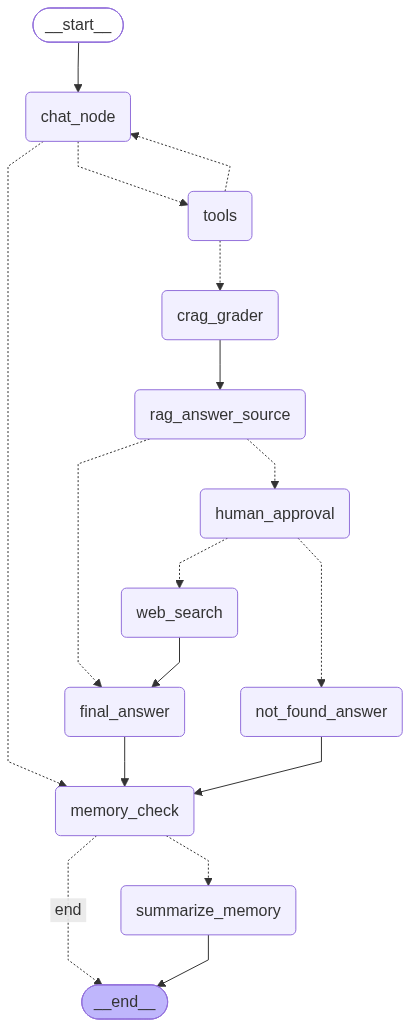

In [2]:
from IPython.display import Image,display
display(Image(chatbot.get_graph().draw_mermaid_png()))